# Kernel Trick Demo
Generate 2D nonlinearly separable data with a circular boundary, visualize its distribution, apply Linear Discriminant Analysis (LDA) and plot its decision boundary, then apply a Support Vector Classifier (SVC) with a polynomial kernel and plot its decision boundary, and investigate why LDA fails and SVC succeeds with a polynomial kernel for this type of data (and when SVC may fail)

### Nonlinearly Separable Data
Generate data points where points inside a circular _decision boundary_ have one class label and points outside have another class label, creating a nonlinearly separable dataset.


In [ ]:
from sklearn.datasets import make_circles

# Generate 500 samples of 2D data
X, y = make_circles(n_samples=500, noise=0.04, random_state=42)

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (500, 2)
Shape of y: (500,)



### Visualize Data Distribution
Create a scatter plot of the generated data, coloring points by their respective class labels.


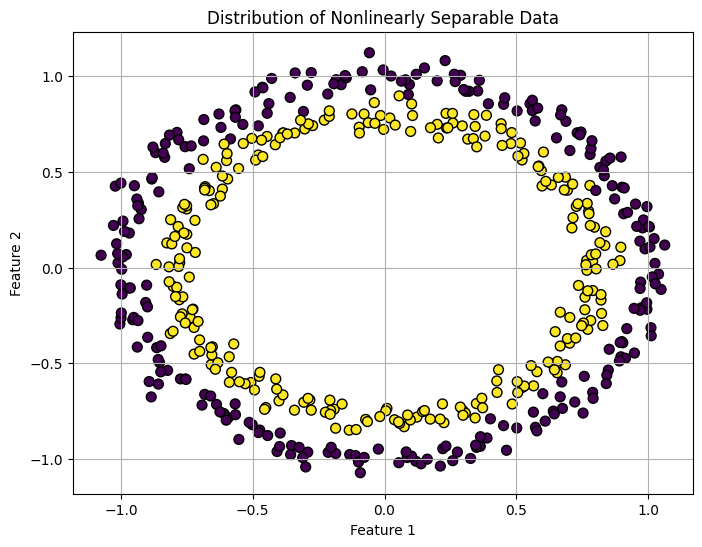

In [ ]:
import matplotlib.pyplot as plt

# Create a scatter plot of the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolors='k')
plt.title('Distribution of Nonlinearly Separable Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()


### Apply Linear Discriminant Analysis (LDA)

LDA is a linear classification algorithm, meaning it attempts to find a linear combination of features that separates two or more classes. It assumes that the data for each class is drawn from a Gaussian distribution and that the classes share a common covariance matrix.
Train an LDA model using `LinearDiscriminantAnalysis` from `sklearn.discriminant_analysis`, instantiate it, and then fit the model using the previously generated features `X` and labels `y`.


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Instantiate the LDA model
lda = LinearDiscriminantAnalysis()

# Fit the LDA model to the data
lda.fit(X, y)

print("LDA model fitted successfully.")


Xtest, ytest = make_circles(n_samples=10, noise=0.04, random_state=42)
print(lda.predict(Xtest))
print(lda.score(Xtest, ytest))
print(ytest)

LDA model fitted successfully.
[0 0 1 1 0 0 1 1 0 0]
0.5
[1 0 1 0 1 0 1 0 0 1]


Plot the data and overlay the linear decision boundary learned by the LDA model to visually demonstrate its inability to accurately separate the classes.



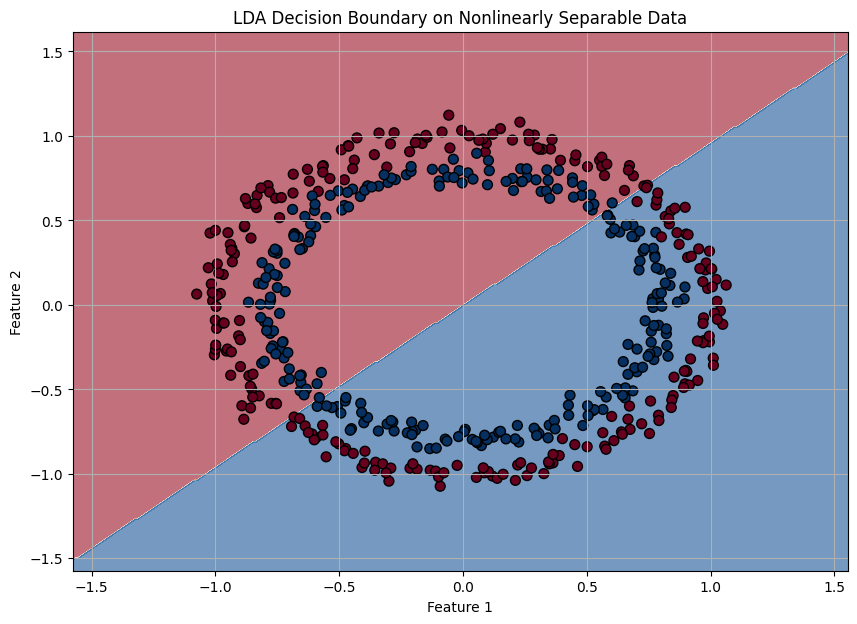

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y, title):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    h = 0.01  # step size in the mesh

    # Generate a meshgrid of points with step size h
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                           np.arange(y_min, y_max, h))

    # Predict the class for each point in the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour and the examples
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdBu, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu, s=50, edgecolors='k')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)
    plt.show()

# Call the function to plot the LDA decision boundary
plot_decision_boundary(lda, X, y, 'LDA Decision Boundary on Nonlinearly Separable Data')


### Apply Support Vector Classifier (SVC)
Support Vector Machines (SVMs), and specifically the Support Vector Classifier (SVC) when used for classification, are powerful algorithms capable of handling both linearly and nonlinearly separable data. When a polynomial kernel is employed, SVC implicitly maps the original features into a higher-dimensional feature space where the data points might become linearly separable.
Train an SVC model using a polynomial kernel on the same 2D data to demonstrate its ability to handle nonlinear separation.


In [ ]:
from sklearn.svm import SVC

# Instantiate the SVC model with a polynomial kernel
svc_poly = SVC(kernel='rbf', random_state=42)

# Fit the SVC model to the data
svc_poly.fit(X, y)

print("SVC model with polynomial kernel fitted successfully.")

SVC model with polynomial kernel fitted successfully.



Plot the data and visualize the SVC  decision boundary.

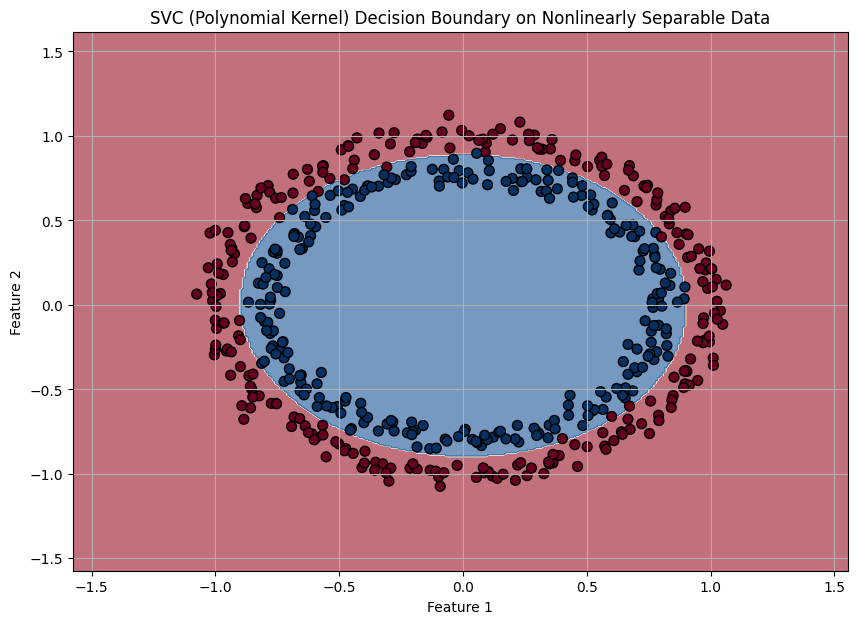

0.9
[1 0 1 1 1 0 1 0 0 1]
[1 0 1 0 1 0 1 0 0 1]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Call the function to plot the SVC decision boundary
plot_decision_boundary(svc_poly, X, y, 'SVC (Polynomial Kernel) Decision Boundary on Nonlinearly Separable Data')

print(svc_poly.score(Xtest, ytest))
print(svc_poly.predict(Xtest))
print(ytest)


### Summary
Provide a summary explaining why Linear Discriminant Analysis (LDA) fails to separate the nonlinearly separable data and when Support Vector Classifier (SVC) with a polynomial kernel succeeds, relating it to their underlying principles. What is the degree of the polynomial kernel that successfully separates the data?